<a href="https://colab.research.google.com/github/KanishkaGajendran/Miniproject3/blob/main/Mini_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Employee Attrition Analysis and Prediction**

In [10]:
from google.colab import files
uploaded=files.upload()

Saving Employee-Attrition.xlsx to Employee-Attrition (1).xlsx


In [56]:
#Read the dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_excel('Employee-Attrition.xlsx')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


#**DATA PREPROCESSING**

In [57]:
#check null values in each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [58]:
#Remove unwanted columns
drop_columns=['BusinessTravel','EducationField','EmployeeCount','EmployeeNumber',
              'EnvironmentSatisfaction','HourlyRate','JobRole',
              'Over18','StandardHours','StockOptionLevel']
df.drop(drop_columns,axis=1,inplace=True)

df

,Age,Attrition,DailyRate,Department,DistanceFromHome,Education,Gender,JobInvolvement,JobLevel,JobSatisfaction,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,1102,Sales,1,2,Female,3,2,4,...,11,3,1,8,0,1,6,4,0,5
1,49,No,279,Research & Development,8,1,Male,2,2,2,...,23,4,4,10,3,3,10,7,1,7
2,37,Yes,1373,Research & Development,2,2,Male,2,1,3,...,15,3,2,7,3,3,0,0,0,0
3,33,No,1392,Research & Development,3,4,Female,3,1,3,...,11,3,3,8,3,3,8,7,3,0
4,27,No,591,Research & Development,2,1,Male,3,1,2,...,12,3,4,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,884,Research & Development,23,2,Male,4,2,4,...,17,3,3,17,3,3,5,2,0,3
1466,39,No,613,Research & Development,6,1,Male,2,3,1,...,15,3,1,9,5,3,7,7,1,7
1467,27,No,155,Research & Development,4,3,Male,4,2,2,...,20,4,2,6,0,3,6,2,0,3
1468,49,No,1023,Sales,2,3,Male,2,2,2,...,14,3,4,17,3,2,9,6,0,8


In [59]:
#IQR outlinear handling
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for column in numerical_columns:
    if column == 'PerformanceRating':
        continue   # 🚀 skip target column

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]



#**ENCODING**

In [61]:
#Encode categorical value
Department_mapping={'Sales':0,'Research & Development':1,'Human Resources':2}
df['Department']=df['Department'].map(Department_mapping)

Gender_mapping={'Male':0,'Female':1}
df['Gender']=df['Gender'].map(Gender_mapping)

MaritalStatus_mapping={'Single':0,'Married':1,'Divorced':2}
df['MaritalStatus']=df['MaritalStatus'].map(MaritalStatus_mapping)

Attrition_mapping={'Yes':1,'No':0}
df['Attrition']=df['Attrition'].map(Attrition_mapping)

OverTime_mapping={'Yes':1,'No':0}
df['OverTime']=df['OverTime'].map(OverTime_mapping)


#**EXPLORATORY DATA ANALYSIS**

Attrition
0    733
1    156
Name: count, dtype: int64
Attrition
0    82.452193
1    17.547807
Name: proportion, dtype: float64


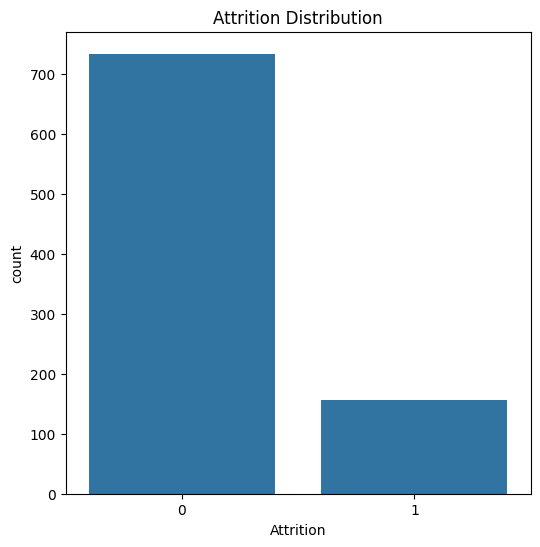

In [62]:
#Attrition Distribution
attrition_counts=df['Attrition'].value_counts()
attrition_percentages=df['Attrition'].value_counts(normalize=True)*100

print(attrition_counts)
print(attrition_percentages)

plt.figure(figsize=(6,6))
sns.countplot(data=df,x='Attrition')
plt.title('Attrition Distribution')
plt.show()

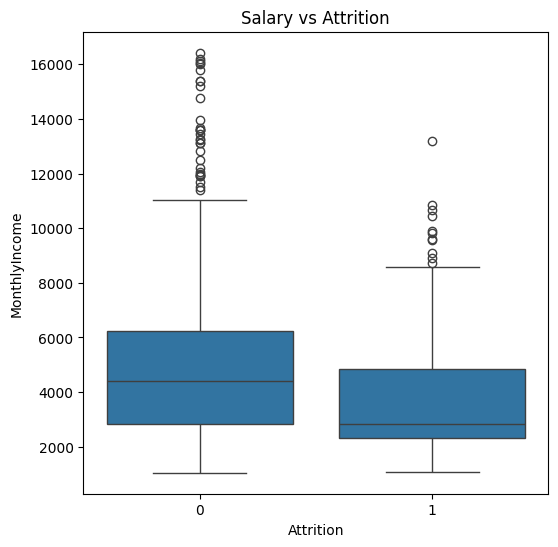

In [63]:
#Salary vs Attrition
plt.figure(figsize=(6,6))
sns.boxplot(data=df,x='Attrition',y='MonthlyIncome')
plt.title('Salary vs Attrition')
plt.show()

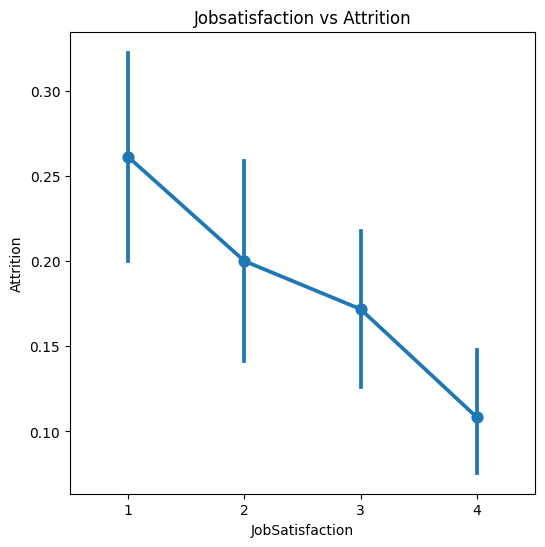

In [64]:
#Jobsatisfaction vs Attrition
plt.figure(figsize=(6,6))
sns.pointplot(data=df,x='JobSatisfaction',y='Attrition')
plt.title('Jobsatisfaction vs Attrition')
plt.show()

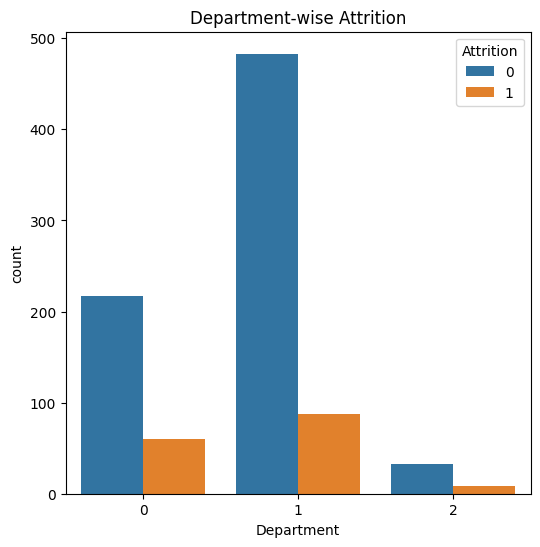

In [65]:
#Department-wise Attrition
plt.figure(figsize=(6,6))
sns.countplot(data=df,x='Department',hue='Attrition')
plt.title('Department-wise Attrition')
plt.show()

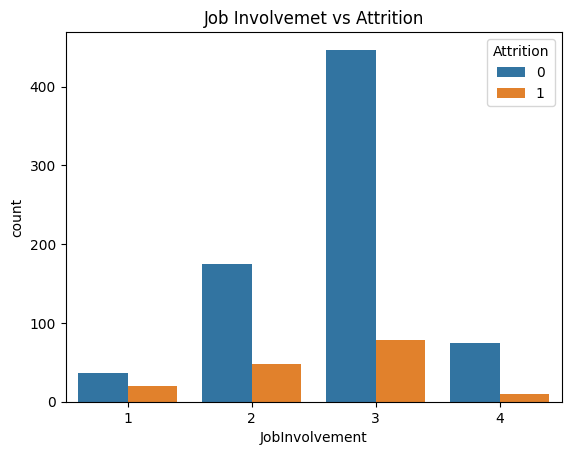

In [66]:
#Job Involvemet vs Attrition

plt.figure()
sns.countplot(data=df,x='JobInvolvement',hue='Attrition')
plt.title('Job Involvemet vs Attrition')
plt.show()

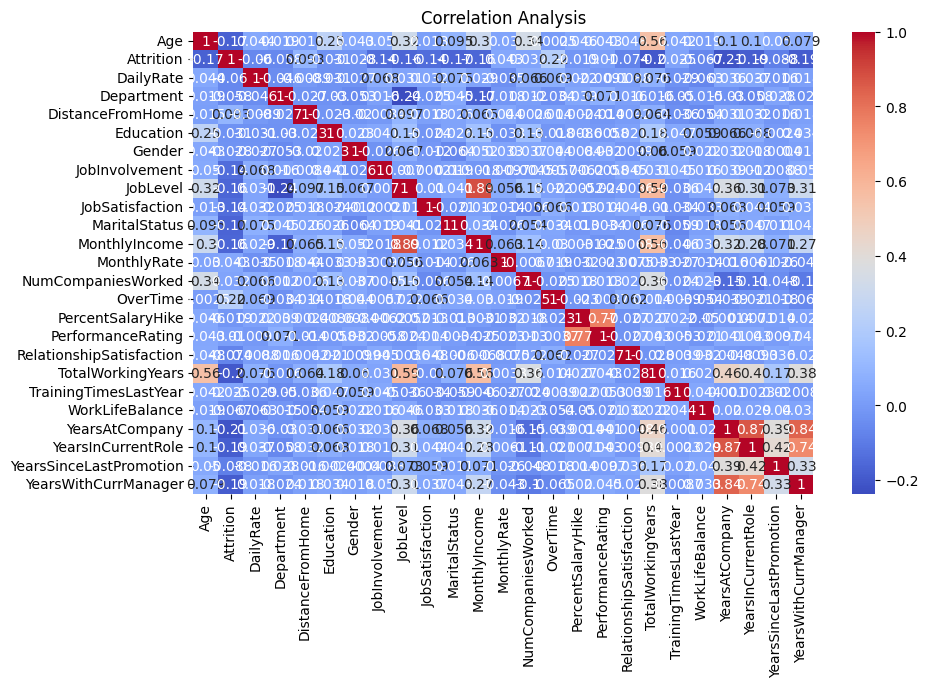

In [67]:
#Correlation Analysis
correlation_matrix=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Analysis')
plt.show()

#**MACHINE LEARNING MODEL TRAINING**

In [68]:
#Bulid a model using randomforest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

features=[
    'Age',
    'Department',
    'MonthlyIncome',
    'JobSatisfaction',
    'YearsAtCompany',
    'MaritalStatus',
    'OverTime'
]

X=df[features]
y=df['Attrition']

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

smote=SMOTE(random_state=42)
x_train_resampled,y_train_resampled=smote.fit_resample(x_train,y_train)

rf_model=RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=5,min_samples_leaf=2,class_weight='balanced',random_state=42)
rf_model.fit(x_train_resampled,y_train_resampled)

y_pred=rf_model.predict(x_test)
y_prob=rf_model.predict_proba(x_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC Score :", roc_auc_score(y_test, y_prob))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.8089887640449438
Precision : 0.43478260869565216
Recall : 0.3225806451612903
F1 Score : 0.37037037037037035
ROC AUC Score : 0.7188940092165899
Confusion Matrix :
 [[134  13]
 [ 21  10]]


In [70]:
# model buliding using decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

features = ['Education',
            'JobInvolvement',
            'JobLevel',
            'MonthlyIncome',
            'YearsAtCompany',
            'YearsInCurrentRole',
            'YearsSinceLastPromotion',
            'TrainingTimesLastYear'
            ]

X=df[features]
y=df['PerformanceRating']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

dt_model=DecisionTreeClassifier(max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)
dt_model.fit(X_train,y_train)

y_pred=dt_model.predict(X_test)
y_prob=dt_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred,average='weighted'))
print("Recall :", recall_score(y_test, y_pred,average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred,average='weighted'))
print("ROC AUC Score :", roc_auc_score(y_test, y_prob,multi_class='ovr'))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))



Accuracy : 0.8089887640449438
Precision : 0.7643189915045216
Recall : 0.8089887640449438
F1 Score : 0.7814117703189486
ROC AUC Score : 0.5530952380952381
Confusion Matrix :
 [[140  10]
 [ 24   4]]


In [71]:
import pickle

with open('rf_model.pkl','wb') as file:
  pickle.dump(rf_model,file)
with open('dt_model.pkl','wb') as file:
  pickle.dump(dt_model,file)
with open('scaler.pkl','wb') as file:
  pickle.dump(scaler,file)